# **Loan Prediction Analysis**

In [2]:
# Importing library
import pandas as pd

# loading dataset
df = pd.read_csv('/content/loan-prediction (1).csv')
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.shape

(614, 13)

# Exploratory Data Analysis(EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Categorical Variables

In [5]:
# checking unique loan id
df['Loan_ID'].nunique()

614

<Axes: xlabel='Loan_Status'>

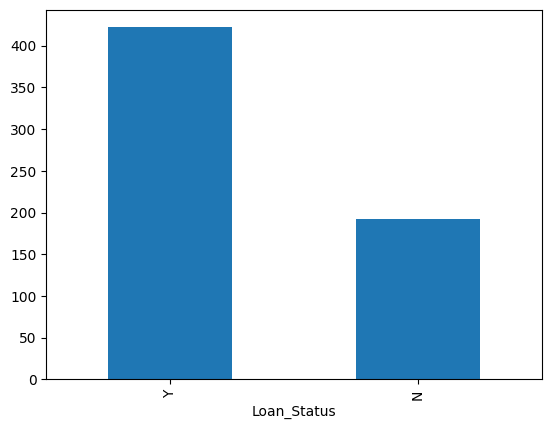

In [6]:
# checking loan status
df['Loan_Status'].value_counts().plot(kind='bar')

In [7]:
# showing loan status in percentange
df['Loan_Status'].value_counts(dropna=False, normalize=True).map("{:.2%}".format)

,proportion
Loan_Status,
Y,68.73%
N,31.27%


# Categorical columns

In [8]:
# Categorical_cols
categorical_cols = df.select_dtypes(include='O').columns.to_list()
print(categorical_cols)

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [9]:
df['Loan_Amount_Term'].dropna().unique()

array([360., 120., 240., 180.,  60., 300., 480.,  36.,  84.,  12.])

In [10]:
df['Credit_History'].dropna().unique()

array([1., 0.])

In [11]:
# removing loan id
categorical_cols.remove('Loan_ID')
categorical_cols = categorical_cols + ['Loan_Amount_Term', 'Credit_History']
print(categorical_cols)

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status', 'Loan_Amount_Term', 'Credit_History']


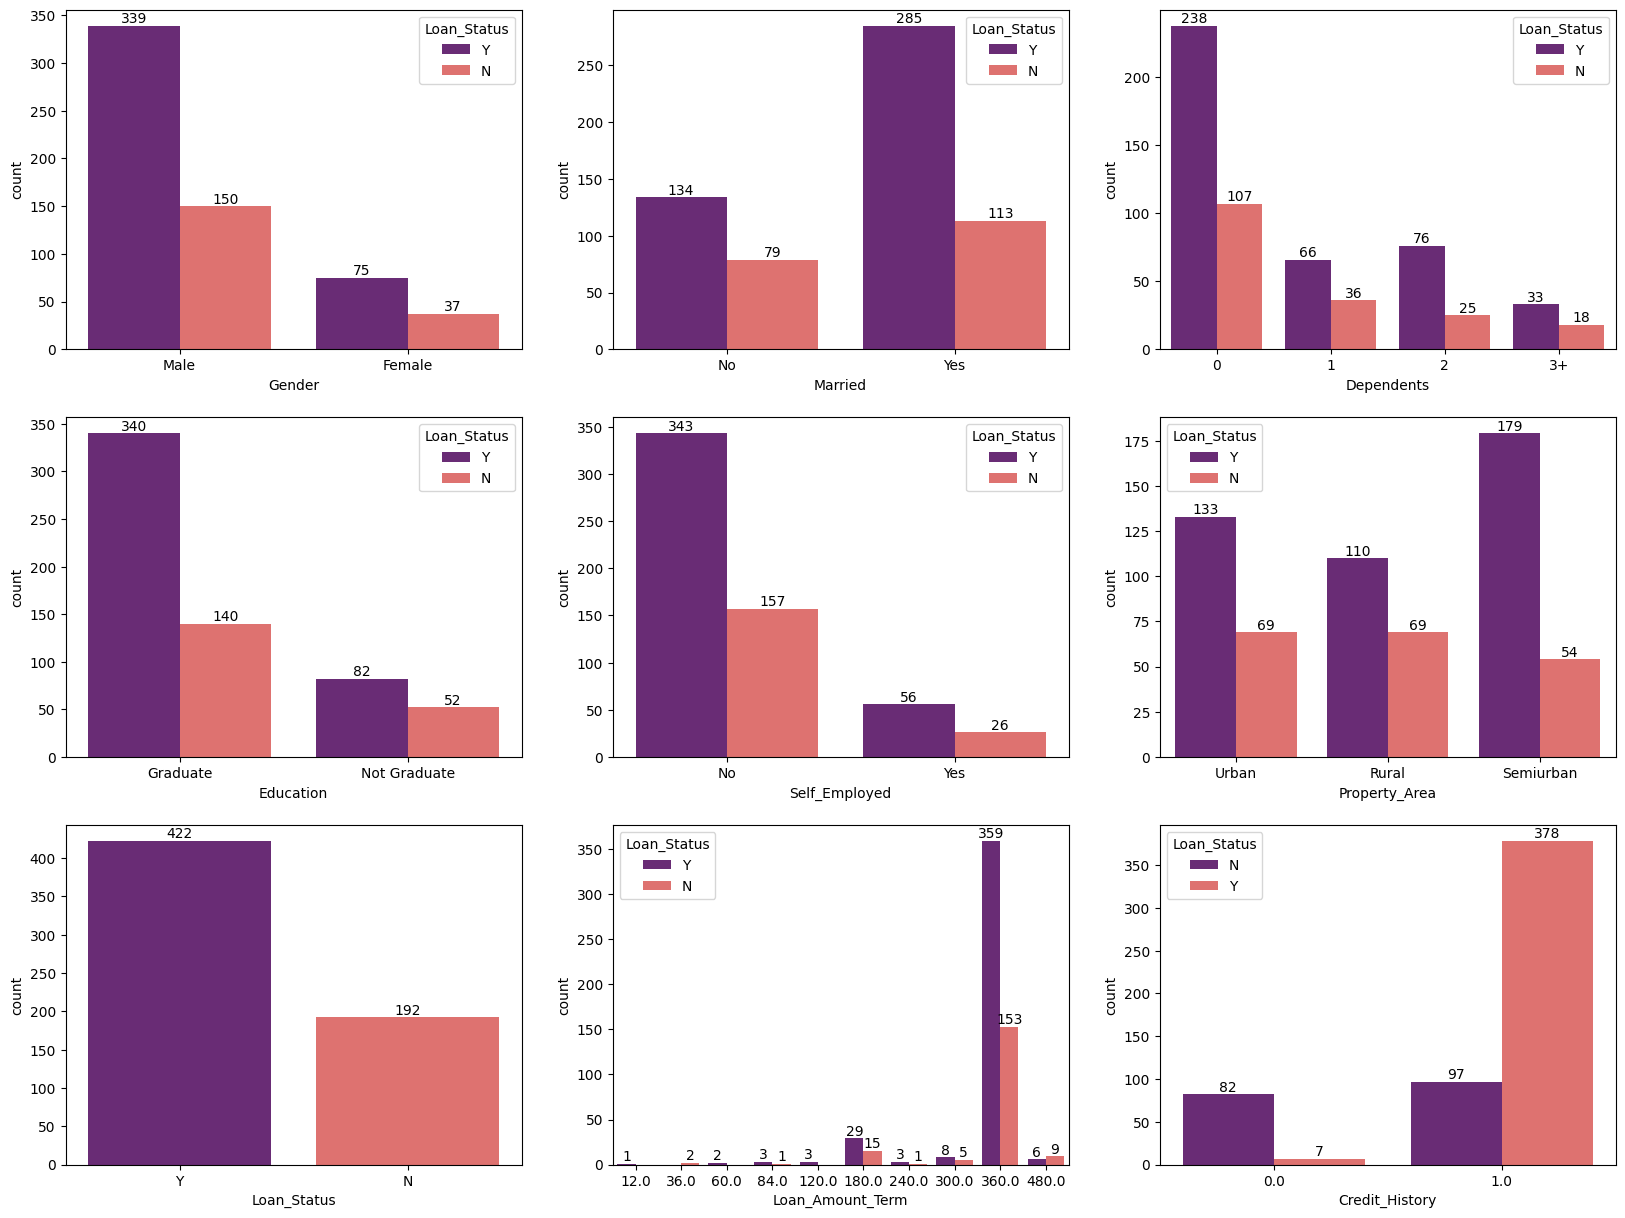

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20,15))
for col, subplot in zip(categorical_cols, axes.flatten()):

  plot = sns.countplot(x=df[col], hue=df['Loan_Status'], ax=subplot, palette='magma')
  for contanier in plot.containers:
    plot.bar_label(contanier)

plt.show()

# Numerical Variables

In [30]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [31]:
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
df[numerical_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount
count,614.000000,614.000000,592.000000
mean,5403.459283,1621.245798,146.412162
std,6109.041673,2926.248369,85.587325
min,150.000000,0.000000,9.000000
25%,2877.500000,0.000000,100.000000
50%,3812.500000,1188.500000,128.000000
75%,5795.000000,2297.250000,168.000000
max,81000.000000,41667.000000,700.000000


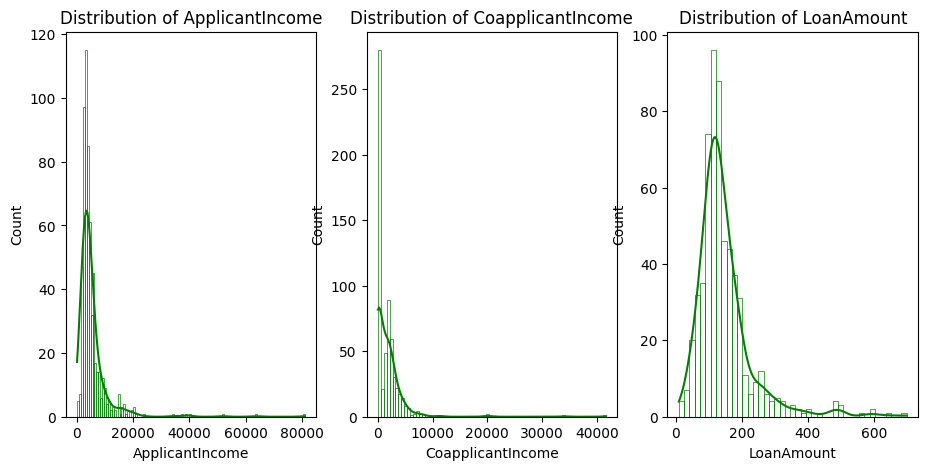

In [34]:
fig, axes = plt.subplots(ncols=3, figsize=(11,5))
for index, col in enumerate(numerical_cols):
  sns.histplot(data=df, x=df[col], ax=axes[index], kde=True, color='green', fill=False).set(title=f'Distribution of {col}')
plt.show()

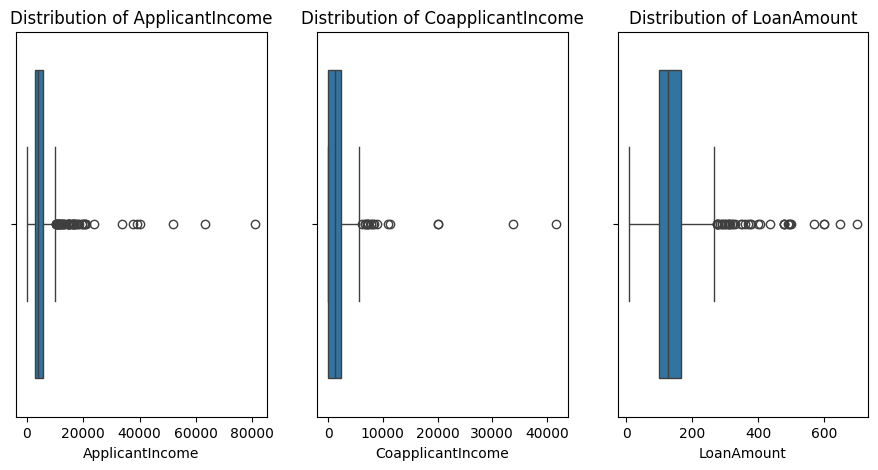

In [35]:
fig, axes = plt.subplots(ncols=3, figsize=(11,5))
for index, col in enumerate(numerical_cols):
  sns.boxplot(data=df, x=col, ax=axes[index]).set(title=f'Distribution of {col}')
plt.show()

In [36]:
df[numerical_cols].corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount
ApplicantIncome,1.000000,-0.116605,0.570909
CoapplicantIncome,-0.116605,1.000000,0.188619
LoanAmount,0.570909,0.188619,1.000000


<Axes: >

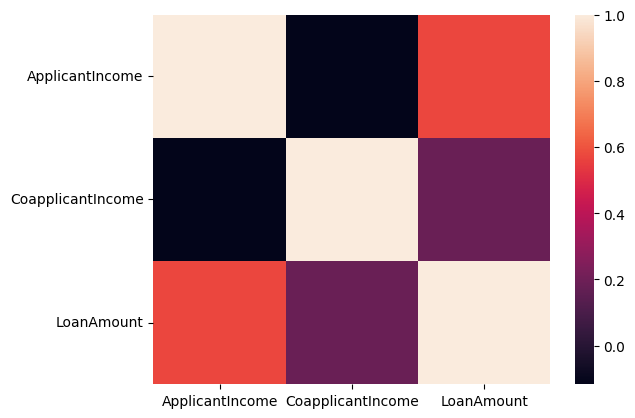

In [37]:
sns.heatmap(df[numerical_cols].corr())

# Bivariate Analysis

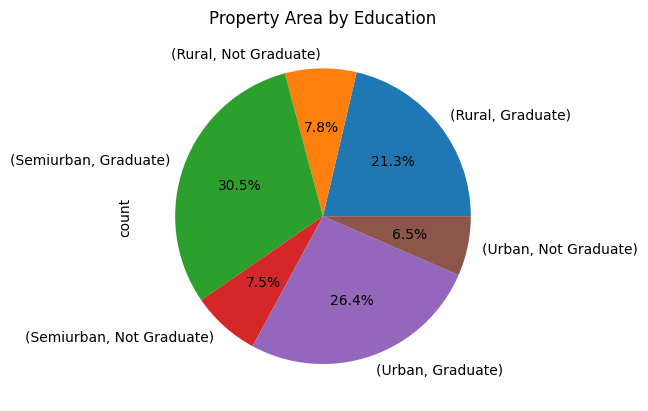

In [41]:
df.groupby('Property_Area').Education.value_counts().plot.pie(autopct="%1.1f%%")
plt.title('Property Area by Education')
plt.show()

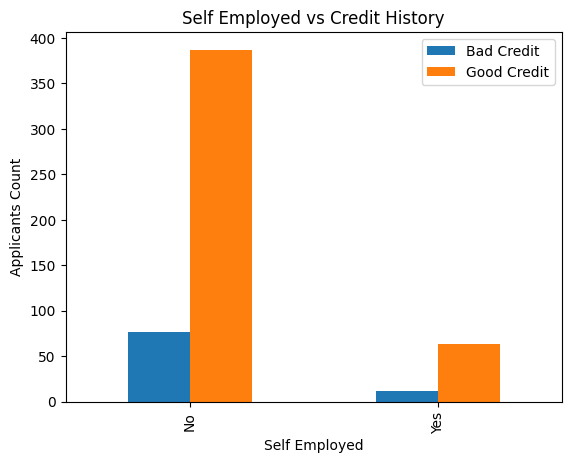

In [43]:
pd.crosstab(df['Self_Employed'], df['Credit_History']).plot.bar()
plt.title('Self Employed vs Credit History')
plt.xlabel('Self Employed')
plt.ylabel('Applicants Count')
plt.legend(['Bad Credit', 'Good Credit'])
plt.show()

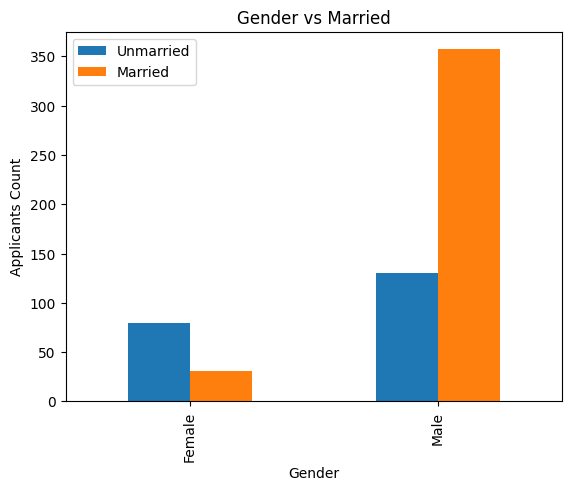

In [46]:
pd.crosstab(df['Gender'], df['Married']).plot.bar()
plt.title('Gender vs Married')
plt.xlabel('Gender')
plt.ylabel('Applicants Count')
plt.legend(['Unmarried', 'Married'])
plt.show()

In [47]:
df.groupby('Education')['Loan_Status'].count()

,Loan_Status
Education,
Graduate,480
Not Graduate,134


In [48]:
df.groupby('Education')['LoanAmount'].describe()

,count,mean,std,min,25%,50%,75%,max
Education,,,,,,,,
Graduate,465.0,154.060215,92.883366,9.0,103.0,132.0,176.0,700.0
Not Graduate,127.0,118.409449,39.773636,25.0,96.5,115.0,133.0,279.0


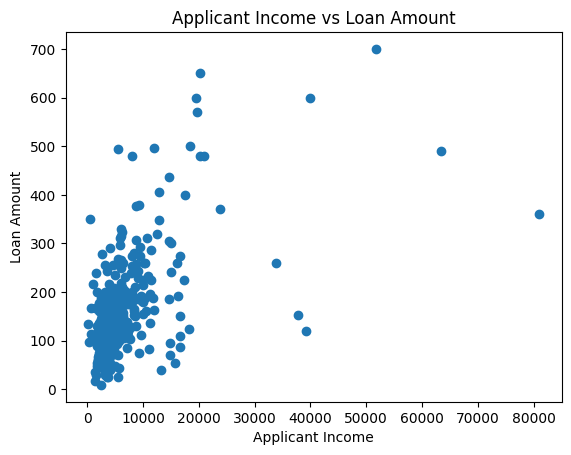

In [49]:
plt.scatter(df['ApplicantIncome'], df['LoanAmount'])
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.title('Applicant Income vs Loan Amount')
plt.show()

<Axes: xlabel='Loan_Amount_Term'>

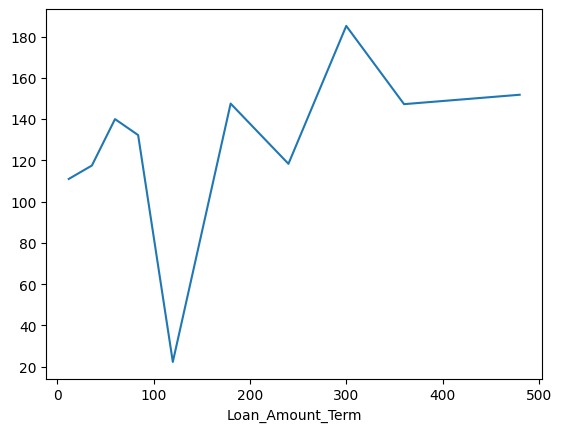

In [50]:
df.groupby('Loan_Amount_Term').LoanAmount.mean().plot()

<Axes: xlabel='Loan_Amount_Term', ylabel='LoanAmount'>

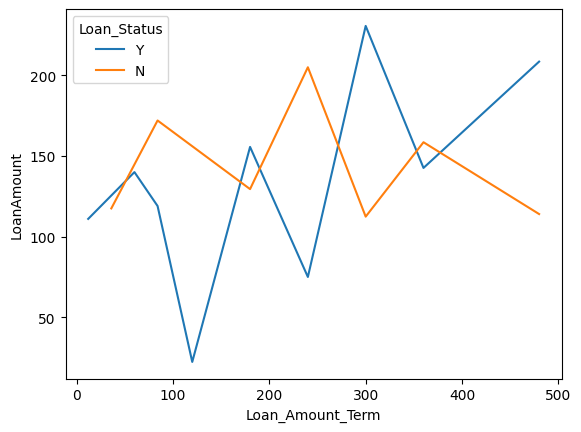

In [51]:
sns.lineplot(x=df['Loan_Amount_Term'], y=df['LoanAmount'], hue=df['Loan_Status'], errorbar=None)

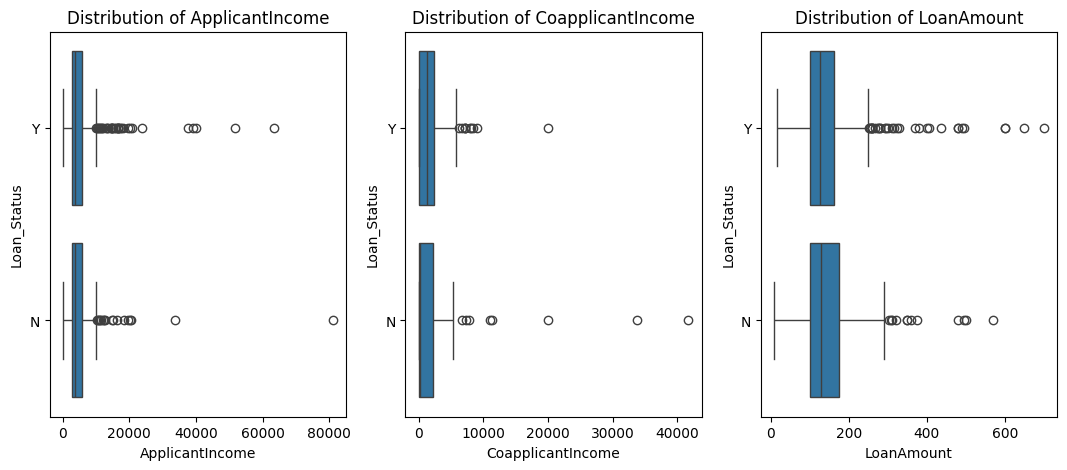

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(ncols=3, figsize=(13,5))
for index, col in enumerate(numerical_cols):
  sns.boxplot(data=df, x=col, y='Loan_Status', ax=axes[index]).set(title=f'Distribution of {col}')
plt.show()

# Data Preprocessing
**Data Cleaning**

In [53]:
# checking null/NaN values
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [55]:
null_count = df.isnull().sum()
null_cols = null_count[null_count>0].index.to_list()
null_cols

['Gender',
 'Married',
 'Dependents',
 'Self_Employed',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

Here major value is categorical

In [56]:
null_cols.remove('LoanAmount')

# Imputation

In [64]:
def fillna_mode(col_name):
  df[col_name].fillna(df[col_name].mode()[0], inplace=True)

for col in null_cols:
  fillna_mode(col)

/tmp/ipykernel_12584/2275093926.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col_name].fillna(df[col_name].mode()[0], inplace=True)


In [63]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

In [65]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# Check for outliers

<Axes: ylabel='LoanAmount'>

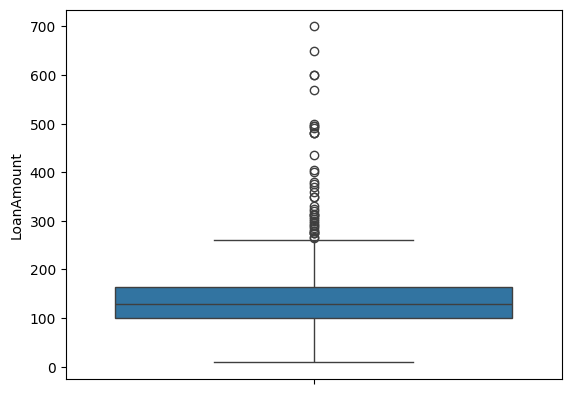

In [66]:
sns.boxplot(df['LoanAmount'])

# Remove outliers

In [67]:
print(numerical_cols)

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']


In [69]:
n = numerical_cols.copy()

Q1 = df[n].quantile(0.25)
Q3 = df[n].quantile(0.75)
IQR = Q3 - Q1

df[n] = df[n][(df[n] >= (Q1 - 1.5*IQR)) & (df[n] <= (Q3 + 1.5*IQR))]

<Axes: ylabel='LoanAmount'>

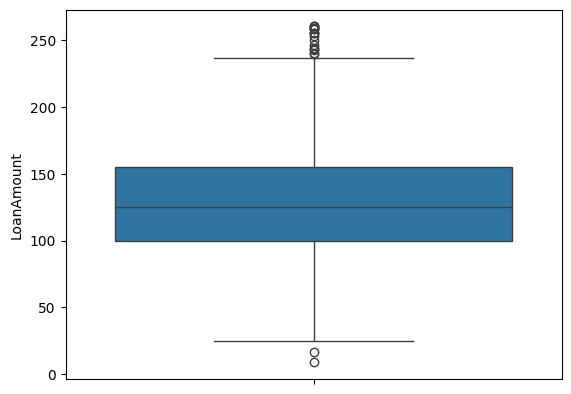

In [70]:
sns.boxplot(df['LoanAmount'])

# Square root transformation to treat Skewed data

In [71]:
def sqrt_transform(col):
  df[col] = (df[col])**(1/2)

for col in numerical_cols:
  sqrt_transform(col)

<Axes: ylabel='Density'>

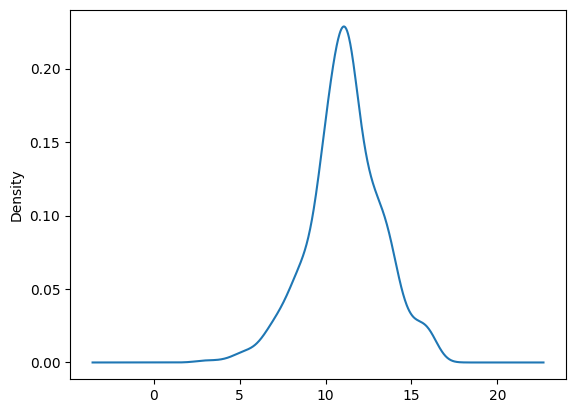

In [72]:
df['LoanAmount'].plot.kde()

array([<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>], dtype=object)

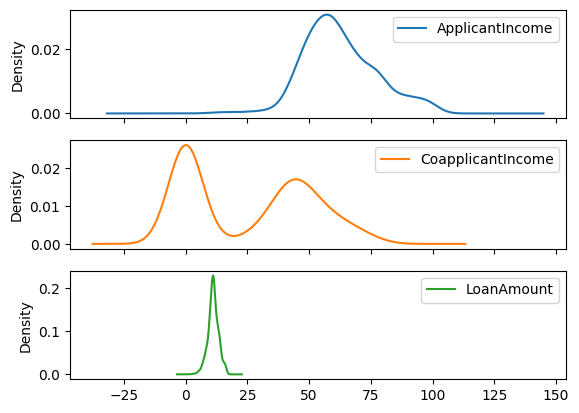

In [74]:
df[numerical_cols].plot(kind='kde', subplots=True)

In [75]:
df[numerical_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount
count,564.000000,596.000000,573.000000
mean,62.565293,25.637303,11.139134
std,14.514855,25.157895,2.100194
min,12.247449,0.000000,3.000000
25%,52.383109,0.000000,10.000000
50%,60.319876,32.109185,11.180340
75%,70.784769,46.615356,12.449900
max,100.692602,75.504967,16.124515


In [76]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,76.478755,0.000000,11.313708,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,67.697858,38.832976,11.313708,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,54.772256,0.000000,8.124038,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,50.823223,48.559242,10.954451,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,77.459667,0.000000,11.874342,360.0,1.0,Urban,Y


# Feature Selection

In [77]:
# Select feature and target
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

In [78]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,76.478755,0.000000,11.313708,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,67.697858,38.832976,11.313708,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,54.772256,0.000000,8.124038,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,50.823223,48.559242,10.954451,360.0,1.0,Urban
4,Male,No,0,Graduate,No,77.459667,0.000000,11.874342,360.0,1.0,Urban


# Feature Engineering

In [80]:
x_cat_cols = X.select_dtypes(include='O').columns
x_cat_cols

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')

In [81]:
x_cat_cols = list(x_cat_cols) + ['Loan_Amount_Term']
print(x_cat_cols)


['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Amount_Term']


# Handle Categorical features

In [82]:
from sklearn.preprocessing import LabelEncoder

X[x_cat_cols] = X[x_cat_cols].apply(LabelEncoder().fit_transform)
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0,0,76.478755,0.000000,11.313708,8,1.0,2
1,1,1,1,0,0,67.697858,38.832976,11.313708,8,1.0,0
2,1,1,0,0,1,54.772256,0.000000,8.124038,8,1.0,2
3,1,1,0,1,0,50.823223,48.559242,10.954451,8,1.0,2
4,1,0,0,0,0,77.459667,0.000000,11.874342,8,1.0,2


In [83]:
df['Credit_History'] = df['Credit_History'].astype(int)

In [84]:
X.dtypes

,0
Gender,int64
Married,int64
Dependents,int64
Education,int64
Self_Employed,int64
ApplicantIncome,float64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,int64
Credit_History,float64


# Feature Scaling

In [85]:
print(numerical_cols)

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])


In [87]:
X.sample(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
233,0,0,0,0,0,1.980417,-1.019912,NaN,8,1.0,1
418,1,1,0,0,0,-2.106586,1.074998,-0.265030,8,1.0,0
92,1,1,2,1,0,-0.369271,0.677261,-1.019431,8,1.0,2
564,1,1,2,0,0,2.154029,-1.019912,2.346234,8,0.0,2
365,1,0,0,1,0,1.122351,-1.019912,0.187493,8,1.0,0
